# Setup 2 — All Markets

Full dataset per market (no intraday clipping), pre-averaged with k ticks,
returns scaled to pips (×10 000). Train on first 80% of observations, test on last 20%.

For each market:
- Fit HMM-AR(1) for K = 1 … 6; select order by AIC
- Compare AR(1) vs HMM mixture (K = 2, 3, 4) on prediction intervals

All expensive model fits are cached in `setup2_results.json`.

## Imports

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.data_utils import load_data, pre_avg, compute_returns
from methods.hmm_fast import (
    fit_single_ar1, predict_single_ar1,
    fit_hmm_robust, predict_hmm_mixture,
    get_filtered_probs, evaluate_predictions
)
from methods.plotting import set_style

set_style()

## Constants

In [34]:
K_TICKS      = 10
TRAIN_FRAC   = 0.8
K_VALS       = [1, 2, 3, 4, 5, 6]
K_PRED       = [2, 3, 4, 5, 6]
K_PRED_VARY  = [2, 3, 4]
markets      = ["EURUSD", "USDJPY", "USDZAR", "XAUUSD"]
RESULTS_FILE = Path("setup2_results.json")

def n_params_hmm(K):
    return 2 * K + K * (K - 1)

## Load and preprocess

Apply pre-averaging directly to the full raw dataset — no intraday clipping.
Overnight and weekend gaps appear as large returns, which the HMM can capture
as high-volatility states.

In [35]:
market_data = {}

for market in markets:
    df_raw = load_data(market=market)
    tmp    = pre_avg(df_raw, tick=True, k=K_TICKS)
    tmp    = compute_returns(tmp)
    y_full = tmp["r"].values.astype(float) * 10_000
    split  = int(TRAIN_FRAC * len(y_full))
    market_data[market] = {
        "y_full":  y_full,
        "y_train": y_full[:split],
        "y_test":  y_full[split:],
    }
    print(f"{market}: {len(y_full):>8,} obs  (train {split:,} / test {len(y_full)-split:,})")

EURUSD:  133,012 obs  (train 106,409 / test 26,603)
USDJPY:  199,406 obs  (train 159,524 / test 39,882)
USDZAR:  323,132 obs  (train 258,505 / test 64,627)
XAUUSD:  753,833 obs  (train 603,066 / test 150,767)


## Fit models — K = 1 … 6 (cached)

Results are written to `setup2_results.json` after the first run.
Re-running the notebook loads from that file and skips all optimization.

In [36]:
if RESULTS_FILE.exists():
    with open(RESULTS_FILE) as f:
        results = json.load(f)
    print(f"Loaded existing results from {RESULTS_FILE}")
else:
    results = {}

for market in markets:
    if market not in results:
        results[market] = {
            "n_train": len(market_data[market]["y_train"]),
            "n_test":  len(market_data[market]["y_test"]),
            "ar1":     {},
            "hmm":     {},
        }

    if not results[market].get("ar1"):
        y_train = market_data[market]["y_train"]
        rho_hat, sigma_hat = fit_single_ar1(y_train)
        results[market]["ar1"] = {
            "rho":   float(rho_hat),
            "sigma": float(sigma_hat),
        }
        with open(RESULTS_FILE, "w") as f:
            json.dump(results, f, indent=2)

    for K in K_VALS:
        if str(K) in results[market]["hmm"]:
            print(f"{market} K={K}: already cached, skipping")
            continue

        y_train = market_data[market]["y_train"]
        print(f"{market} K={K} ...", end=" ", flush=True)
        result, params = fit_hmm_robust(y_train, K=K, n_starts=10, seed=42)
        loglik = float(-result.fun)
        p      = n_params_hmm(K)
        aic    = round(-2 * loglik + 2 * p, 2)
        results[market]["hmm"][str(K)] = {
            "beta":     params["beta"].tolist(),
            "sigma":    params["sigma"].tolist(),
            "P":        params["P"].tolist(),
            "loglik":   loglik,
            "n_params": p,
            "aic":      aic,
        }
        with open(RESULTS_FILE, "w") as f:
            json.dump(results, f, indent=2)
        print(f"AIC = {aic:.1f}  (saved)")

Loaded existing results from setup2_results.json
EURUSD K=1: already cached, skipping
EURUSD K=2: already cached, skipping
EURUSD K=3: already cached, skipping
EURUSD K=4: already cached, skipping
EURUSD K=5: already cached, skipping
EURUSD K=6: already cached, skipping
USDJPY K=1: already cached, skipping
USDJPY K=2: already cached, skipping
USDJPY K=3: already cached, skipping
USDJPY K=4: already cached, skipping
USDJPY K=5: already cached, skipping
USDJPY K=6: already cached, skipping
USDZAR K=1: already cached, skipping
USDZAR K=2: already cached, skipping
USDZAR K=3: already cached, skipping
USDZAR K=4: already cached, skipping
USDZAR K=5: already cached, skipping
USDZAR K=6: already cached, skipping
XAUUSD K=1: already cached, skipping
XAUUSD K=2: already cached, skipping
XAUUSD K=3: already cached, skipping
XAUUSD K=4: already cached, skipping
XAUUSD K=5: already cached, skipping
XAUUSD K=6: already cached, skipping


## Order selection by AIC

In [37]:
aic_records = [
    {"market": market, "K": int(K), "AIC": results[market]["hmm"][str(K)]["aic"]}
    for market in markets
    for K in K_VALS
]
aic_df = pd.DataFrame(aic_records)

print(aic_df.pivot(index="K", columns="market", values="AIC").round(1).to_string())

best_K = {
    market: int(aic_df[aic_df["market"] == market].set_index("K")["AIC"].idxmin())
    for market in markets
}
print("\nBest K by AIC:")
for market, K in best_K.items():
    print(f"  {market}: K = {K}")

market    EURUSD     USDJPY     USDZAR      XAUUSD
K                                                 
1       127738.6  1806793.8  1867669.0  12186266.6
2       120526.2  1781775.4  1726482.1  11957397.5
3       118520.9  1774120.7  1703196.0  11922835.3
4       117321.0  1770292.6  1696724.3  11906993.4
5       116892.0  1769068.8  1693358.1  11899228.8
6       116548.9  1768250.4  1690514.4  11893421.6

Best K by AIC:
  EURUSD: K = 6
  USDJPY: K = 6
  USDZAR: K = 6
  XAUUSD: K = 6


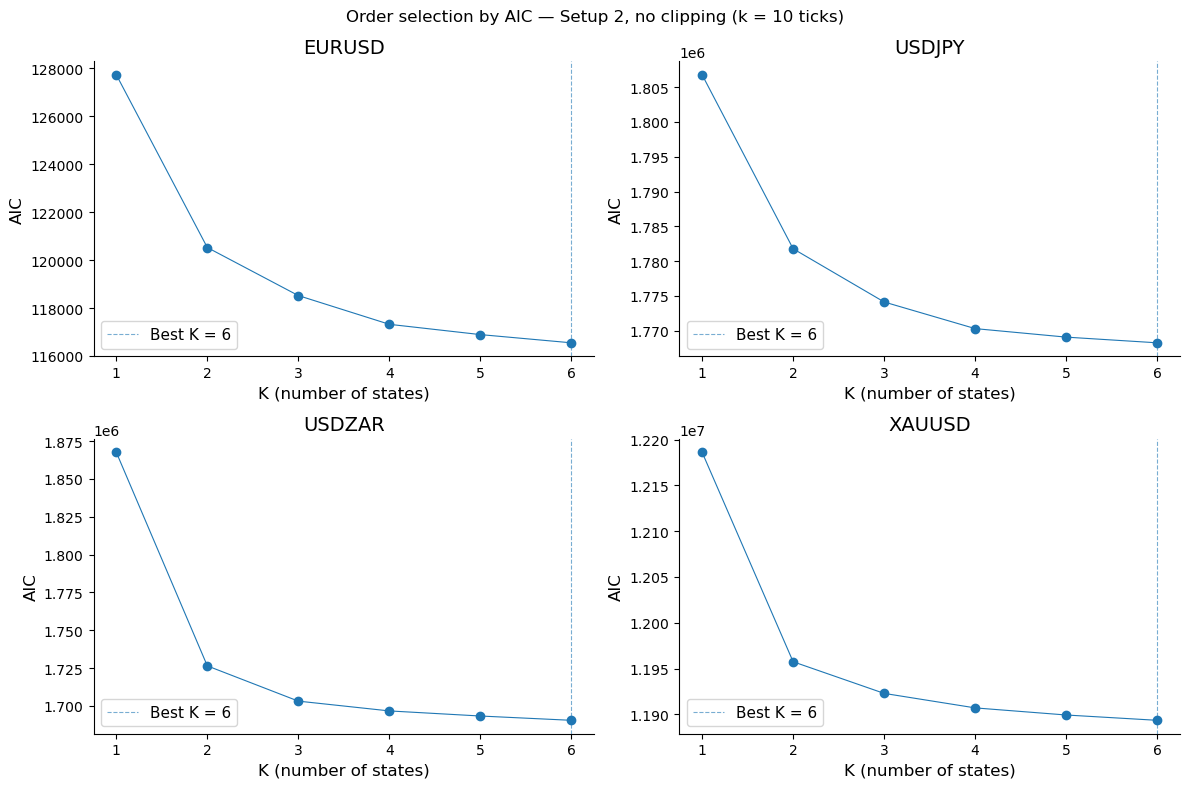

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, market in zip(axes.flat, markets):
    sub = aic_df[aic_df["market"] == market]
    ax.plot(sub["K"], sub["AIC"], marker="o")
    ax.axvline(best_K[market], linestyle="--", alpha=0.6, label=f"Best K = {best_K[market]}")
    ax.set_title(market)
    ax.set_xlabel("K (number of states)")
    ax.set_ylabel("AIC")
    ax.set_xticks(K_VALS)
    ax.legend()

plt.suptitle(f"Order selection by AIC — Setup 2, no clipping (k = {K_TICKS} ticks)")
plt.tight_layout()
plt.savefig("../plots/setup2_aic_all_markets.pdf", bbox_inches="tight")
plt.show()

## Fitted parameters

In [39]:
for market in markets:
    a = results[market]["ar1"]
    print(f"\n{'='*50}")
    print(f"{market}")
    print(f"  AR(1): rho = {a['rho']:.4f},  sigma = {a['sigma']:.4f}")
    for K in K_VALS:
        r = results[market]["hmm"][str(K)]
        print(f"\n  K = {K}  (AIC = {r['aic']:.1f})")
        print(f"    beta : {np.round(r['beta'],  4)}")
        print(f"    sigma: {np.round(r['sigma'], 4)}")
        print(f"    P    :\n{np.round(r['P'], 4)}")


EURUSD
  AR(1): rho = 0.2485,  sigma = 0.4410

  K = 1  (AIC = 127738.6)
    beta : [0.2485]
    sigma: [0.441]
    P    :
[[1.]]

  K = 2  (AIC = 120526.2)
    beta : [0.2459 0.266 ]
    sigma: [0.412  1.1943]
    P    :
[[0.9966 0.0034]
 [0.1695 0.8305]]

  K = 3  (AIC = 118520.9)
    beta : [0.2521 0.2582 0.2243]
    sigma: [1.8287 0.4852 0.3332]
    P    :
[[8.638e-01 1.359e-01 3.000e-04]
 [1.100e-03 9.685e-01 3.050e-02]
 [3.000e-04 3.480e-02 9.649e-01]]

  K = 4  (AIC = 117321.0)
    beta : [ 0.2539 -0.0078  0.2544  0.2496]
    sigma: [1.9824 0.1262 0.5047 0.3933]
    P    :
[[8.254e-01 0.000e+00 1.745e-01 1.000e-04]
 [1.000e-04 7.513e-01 4.220e-02 2.064e-01]
 [1.600e-03 3.700e-03 9.898e-01 4.900e-03]
 [4.000e-04 1.790e-02 3.000e-04 9.814e-01]]

  K = 5  (AIC = 116892.0)
    beta : [ 0.2484  0.2307  0.2527  0.4273 -0.0136]
    sigma: [0.3862 0.8306 0.4743 6.0455 0.1209]
    P    :
[[9.822e-01 0.000e+00 1.000e-04 1.000e-04 1.750e-02]
 [1.600e-03 9.369e-01 5.920e-02 2.000e-04 2.000

## Filtered state probabilities — test set

Shown for the AIC-selected K per market, first 500 observations of the test set.

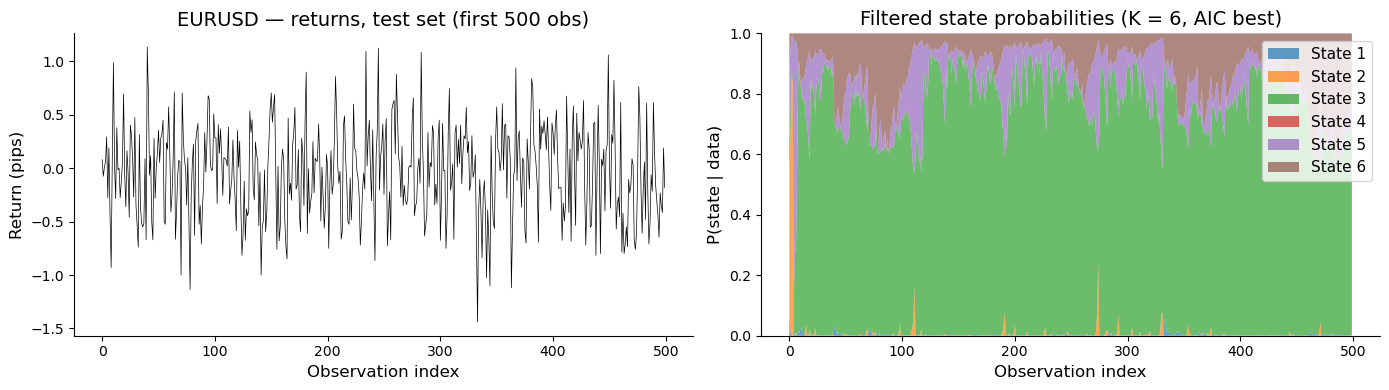

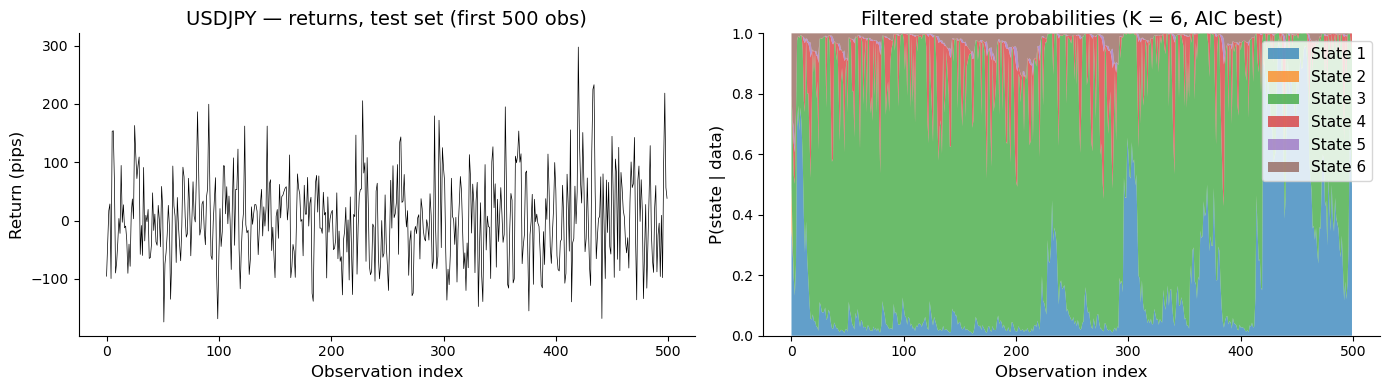

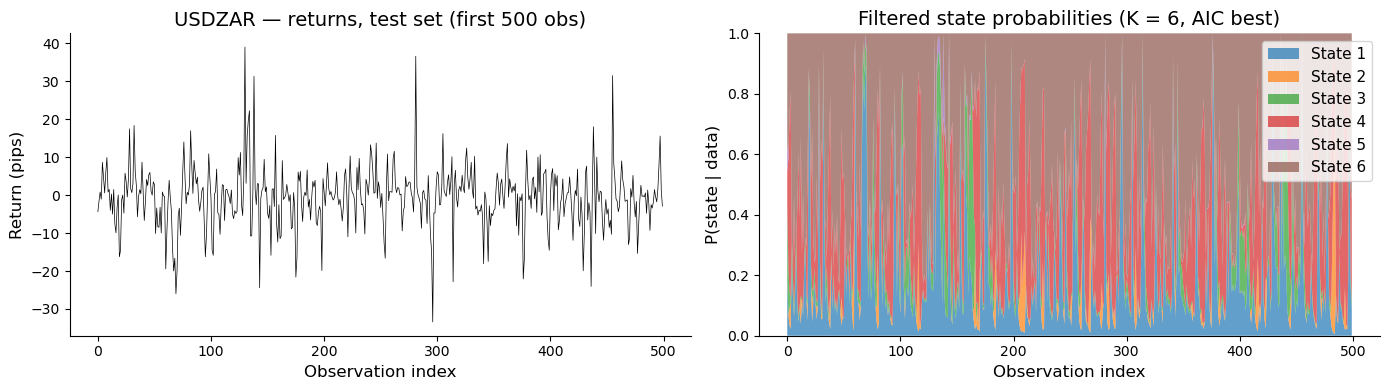

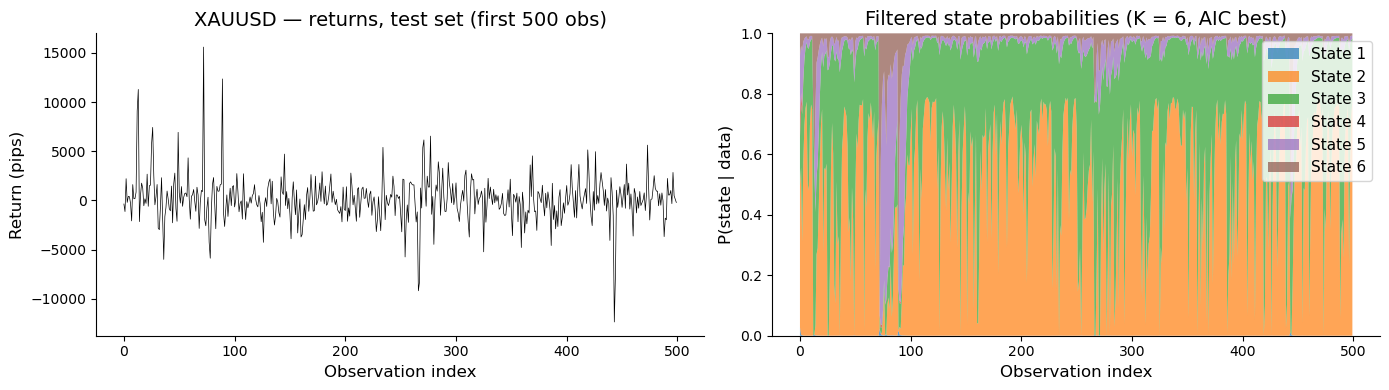

In [40]:
N_SHOW = 500

for market in markets:
    y_test = market_data[market]["y_test"]
    K      = best_K[market]
    r      = results[market]["hmm"][str(K)]
    params = {
        "beta":  np.array(r["beta"]),
        "sigma": np.array(r["sigma"]),
        "P":     np.array(r["P"]),
    }
    alpha = get_filtered_probs(y_test, params)
    t     = np.arange(N_SHOW)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(t, y_test[:N_SHOW], linewidth=0.5, color="black")
    axes[0].set_title(f"{market} — returns, test set (first {N_SHOW} obs)")
    axes[0].set_xlabel("Observation index")
    axes[0].set_ylabel("Return (pips)")

    bottom = np.zeros(N_SHOW)
    for j in range(K):
        top = bottom + alpha[:N_SHOW, j]
        axes[1].fill_between(t, bottom, top, alpha=0.7, label=f"State {j+1}")
        bottom = top
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f"Filtered state probabilities (K = {K}, AIC best)")
    axes[1].set_xlabel("Observation index")
    axes[1].set_ylabel("P(state | data)")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    # plt.savefig(f"../plots/setup2_filtered_{market.lower()}_K{K}.pdf", bbox_inches="tight")
    plt.show()

## Prediction intervals and evaluation

One-step-ahead 95% prediction intervals on the test set.
Compare AR(1) against HMM mixture for K = 2, 3, 4.

In [41]:
all_preds    = {}
eval_records = {}

for market in markets:
    y_train = market_data[market]["y_train"]
    y_test  = market_data[market]["y_test"]
    a       = results[market]["ar1"]

    all_preds[market]    = {}
    eval_records[market] = {}

    pred, lower, upper = predict_single_ar1(
        y_train, y_test, a["rho"], a["sigma"], alpha=0.05
    )
    all_preds[market]["AR(1)"] = (pred, lower, upper)

    for K in K_PRED:
        r      = results[market]["hmm"][str(K)]
        params = {
            "beta":  np.array(r["beta"]),
            "sigma": np.array(r["sigma"]),
            "P":     np.array(r["P"]),
        }
        pred, lower, upper = predict_hmm_mixture(y_train, y_test, params, alpha=0.05)
        all_preds[market][f"HMM K={K}"] = (pred, lower, upper)

    for label, (pred, lower, upper) in all_preds[market].items():
        eval_records[market][label] = evaluate_predictions(
            y_test, pred, lower, upper, alpha=0.05
        )

    print(f"{market} done")

EURUSD done
USDJPY done
USDZAR done
XAUUSD done


In [42]:
for market in markets:
    print(f"\n=== {market} ===")
    print(pd.DataFrame(eval_records[market]).T.round(4).to_string())


=== EURUSD ===
           rmse  coverage  avg_width  interval_score
AR(1)    0.3979    0.9667     1.7287          1.9508
HMM K=2  0.3979    0.9607     1.6702          1.9302
HMM K=3  0.3979    0.9567     1.6371          1.9252
HMM K=4  0.3980    0.9530     1.6081          1.9213
HMM K=5  0.3979    0.9545     1.6158          1.9193
HMM K=6  0.3979    0.9523     1.6008          1.9173

=== USDJPY ===
            rmse  coverage  avg_width  interval_score
AR(1)    66.3261    0.9564   273.1977        345.9574
HMM K=2  66.3345    0.9507   264.2853        334.5491
HMM K=3  66.3446    0.9495   262.3110        334.2571
HMM K=4  66.3449    0.9467   257.5549        328.2759
HMM K=5  66.3487    0.9468   256.4058        325.8318
HMM K=6  66.3596    0.9482   257.2178        325.2148

=== USDZAR ===
           rmse  coverage  avg_width  interval_score
AR(1)    7.5586    0.9617    35.1459         47.8747
HMM K=2  7.5715    0.9606    32.3833         44.8698
HMM K=3  7.5730    0.9589    31.4222        

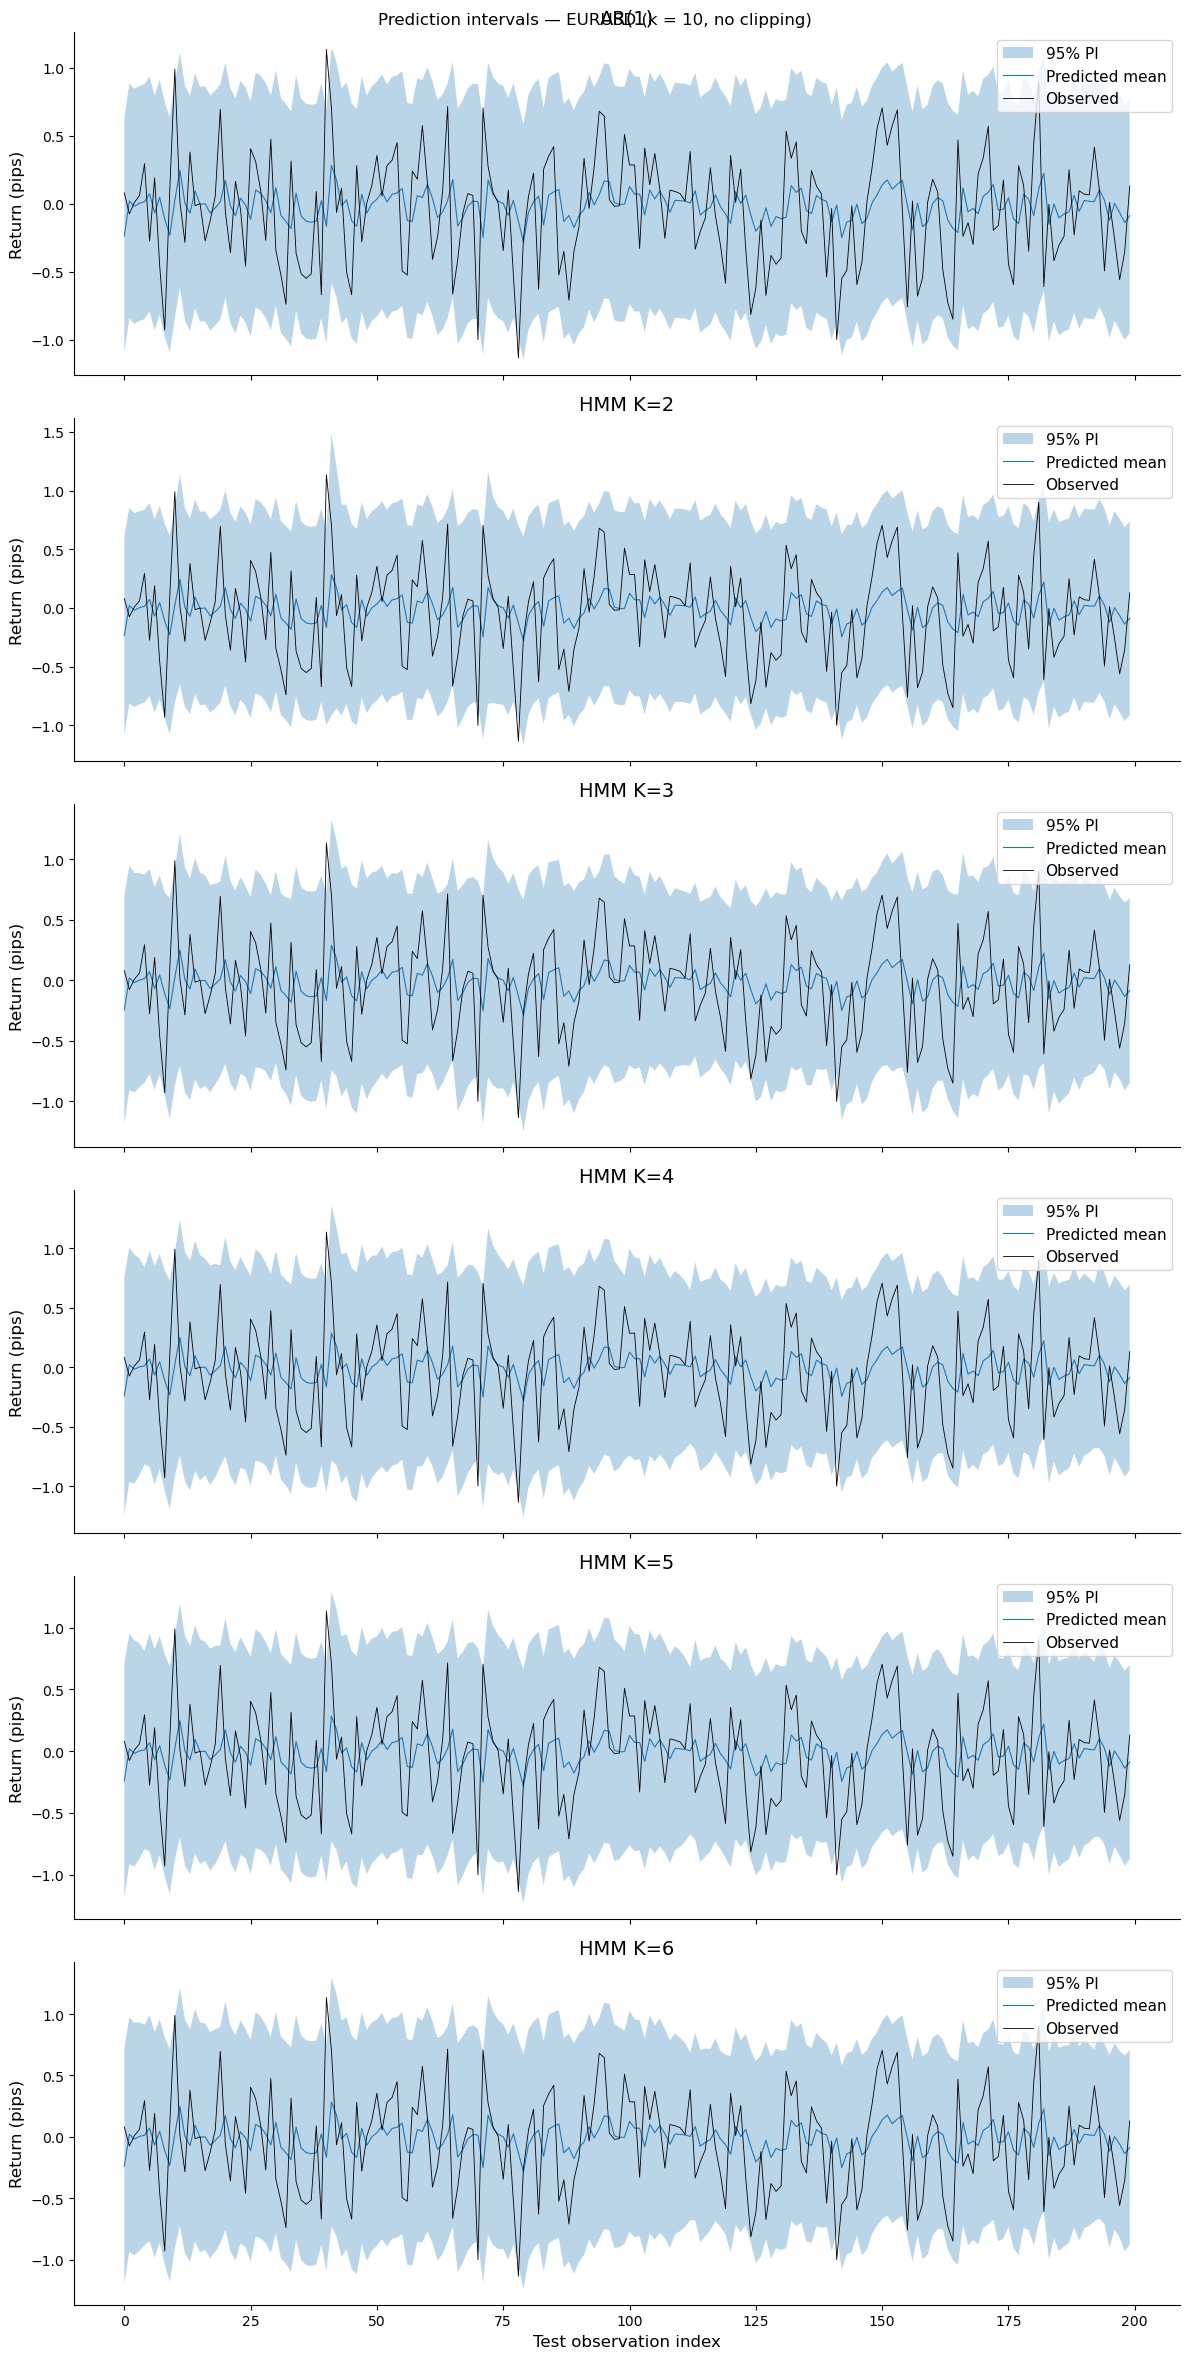

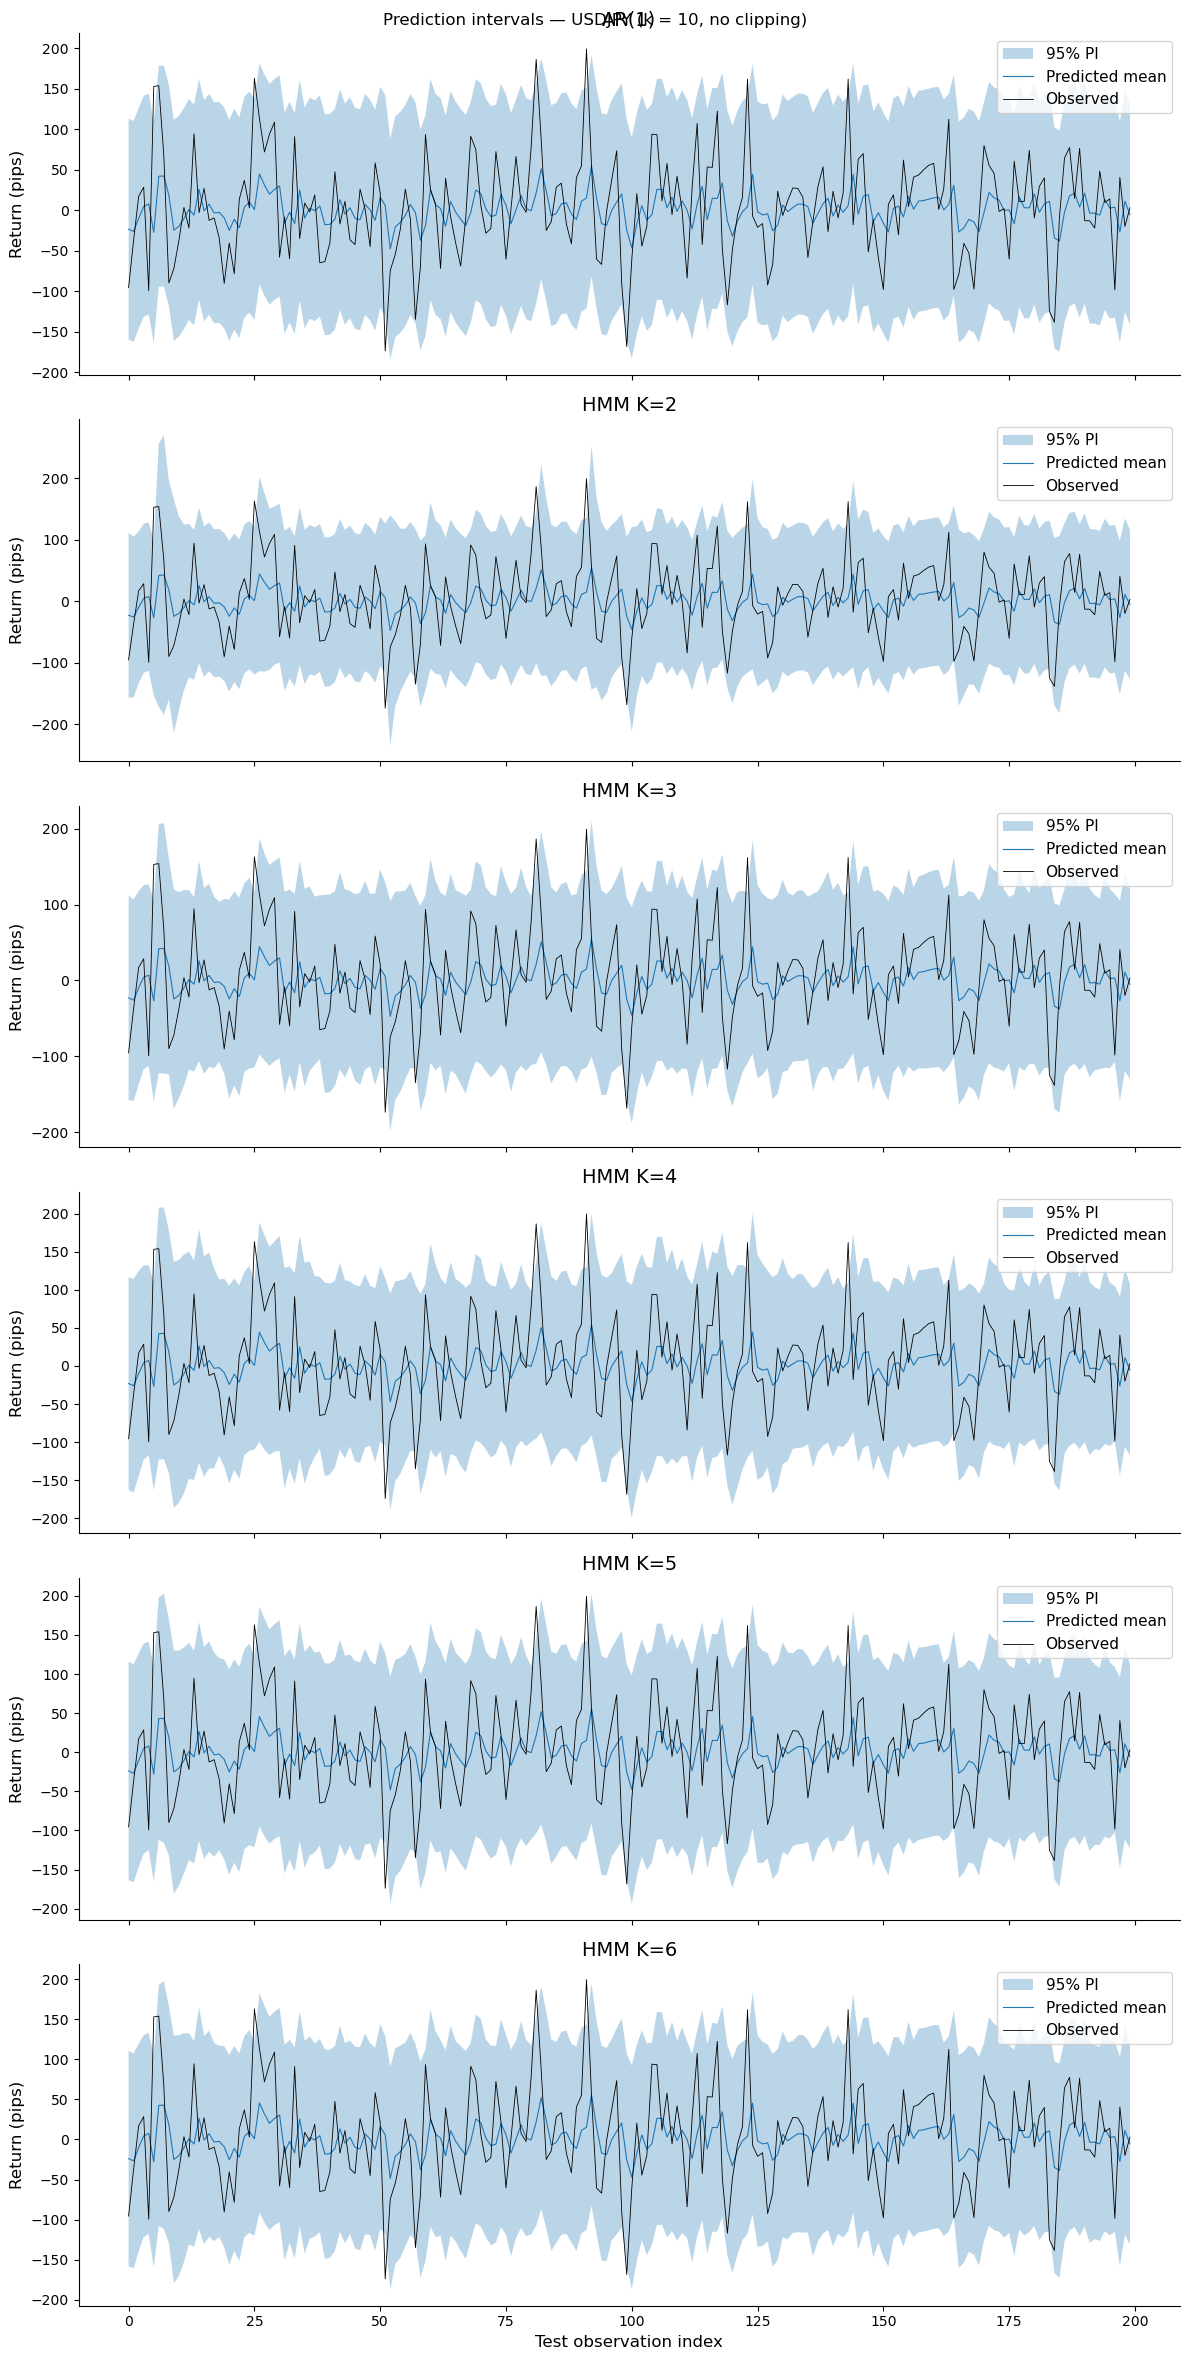

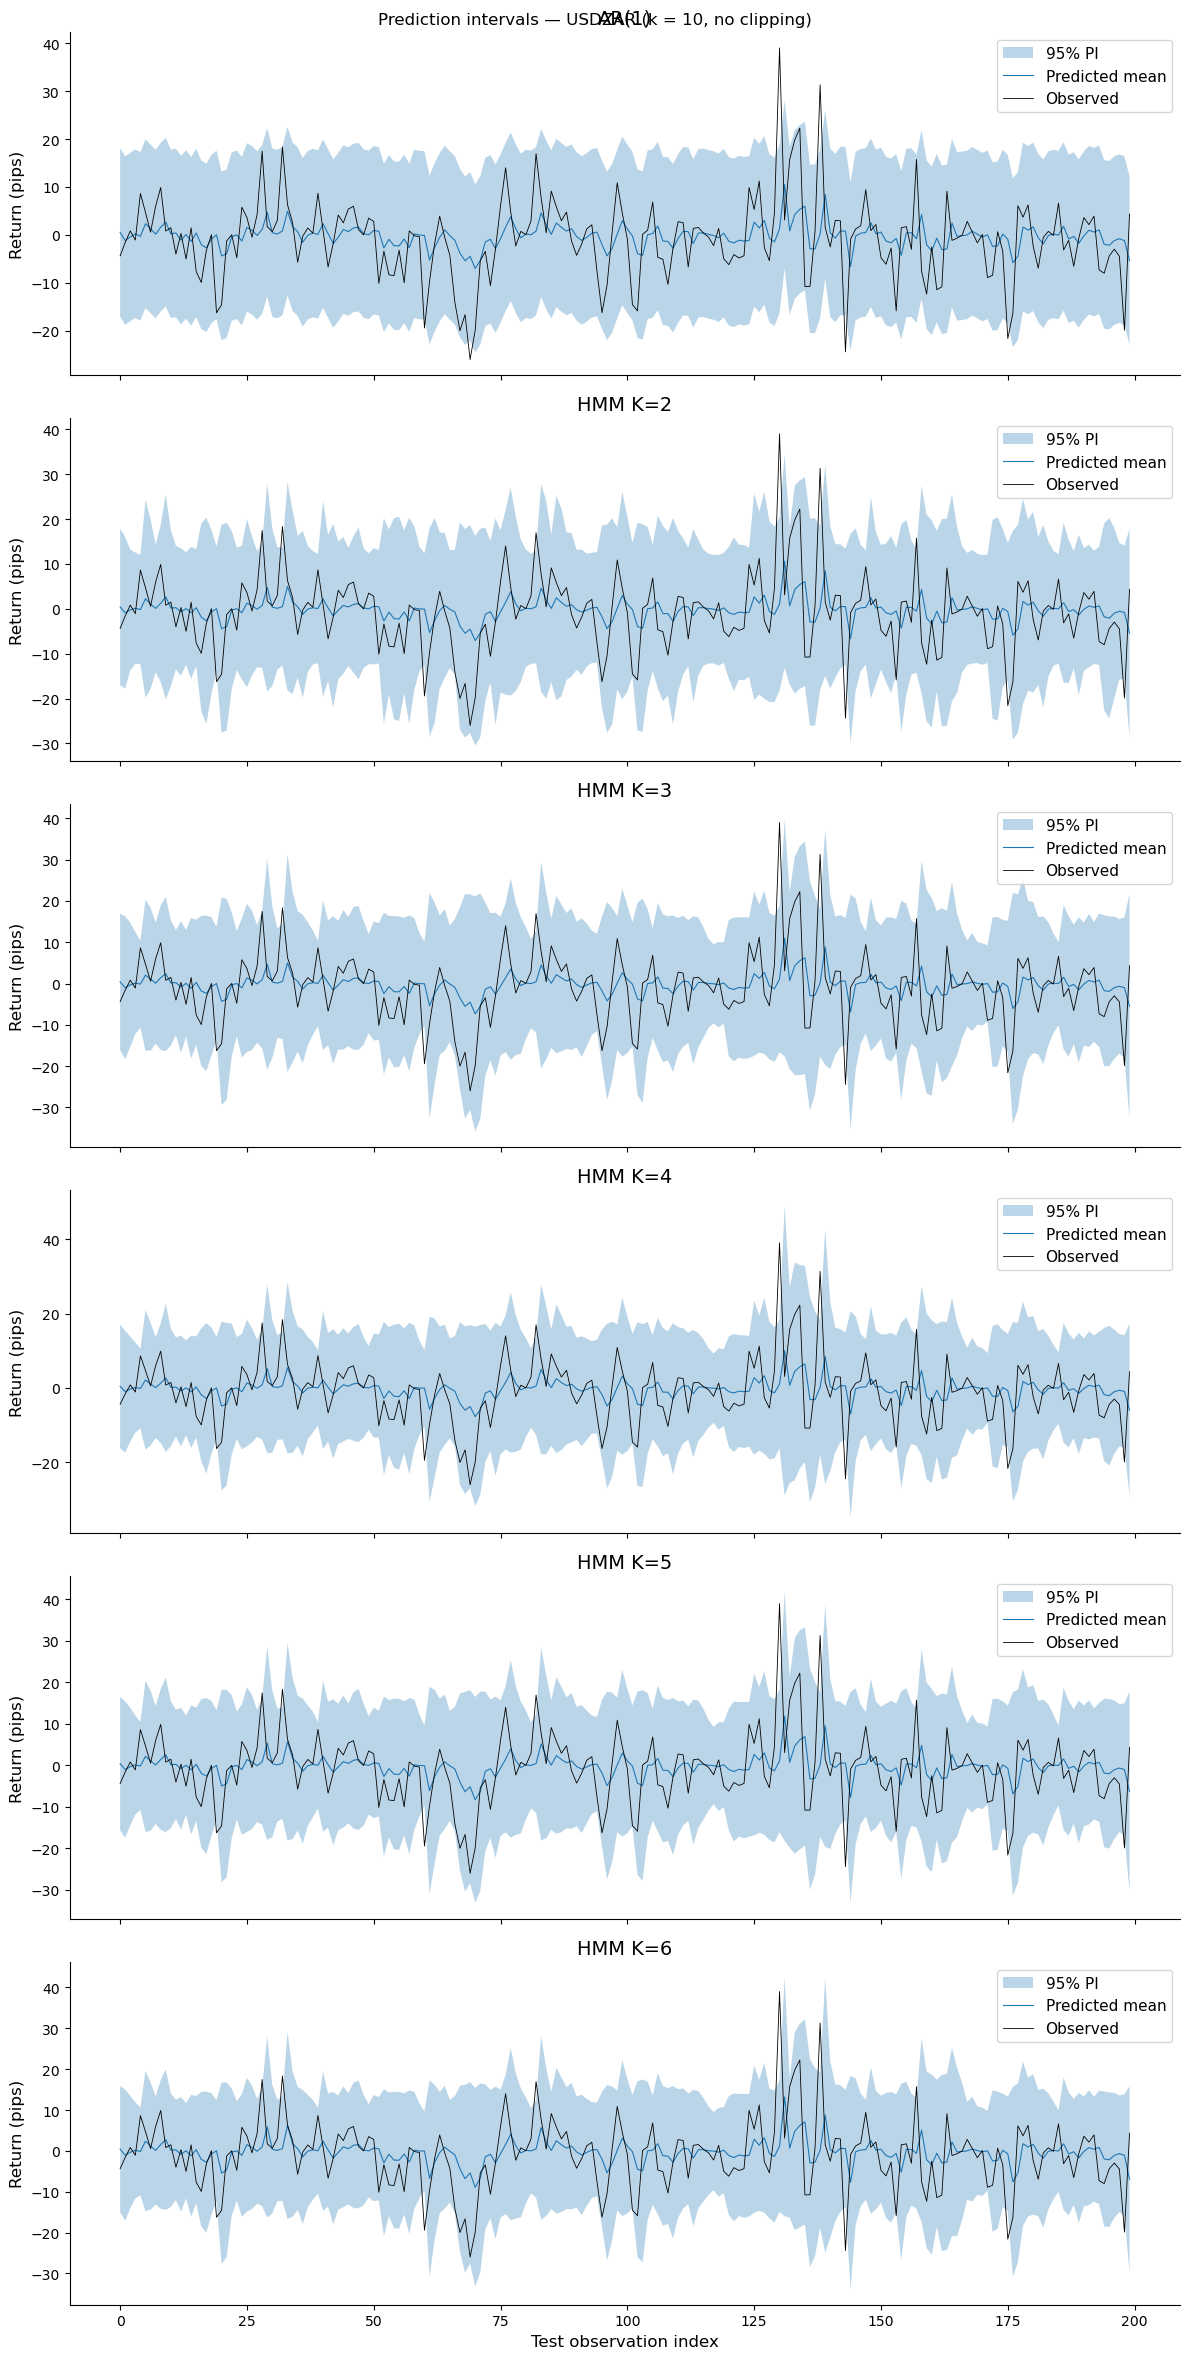

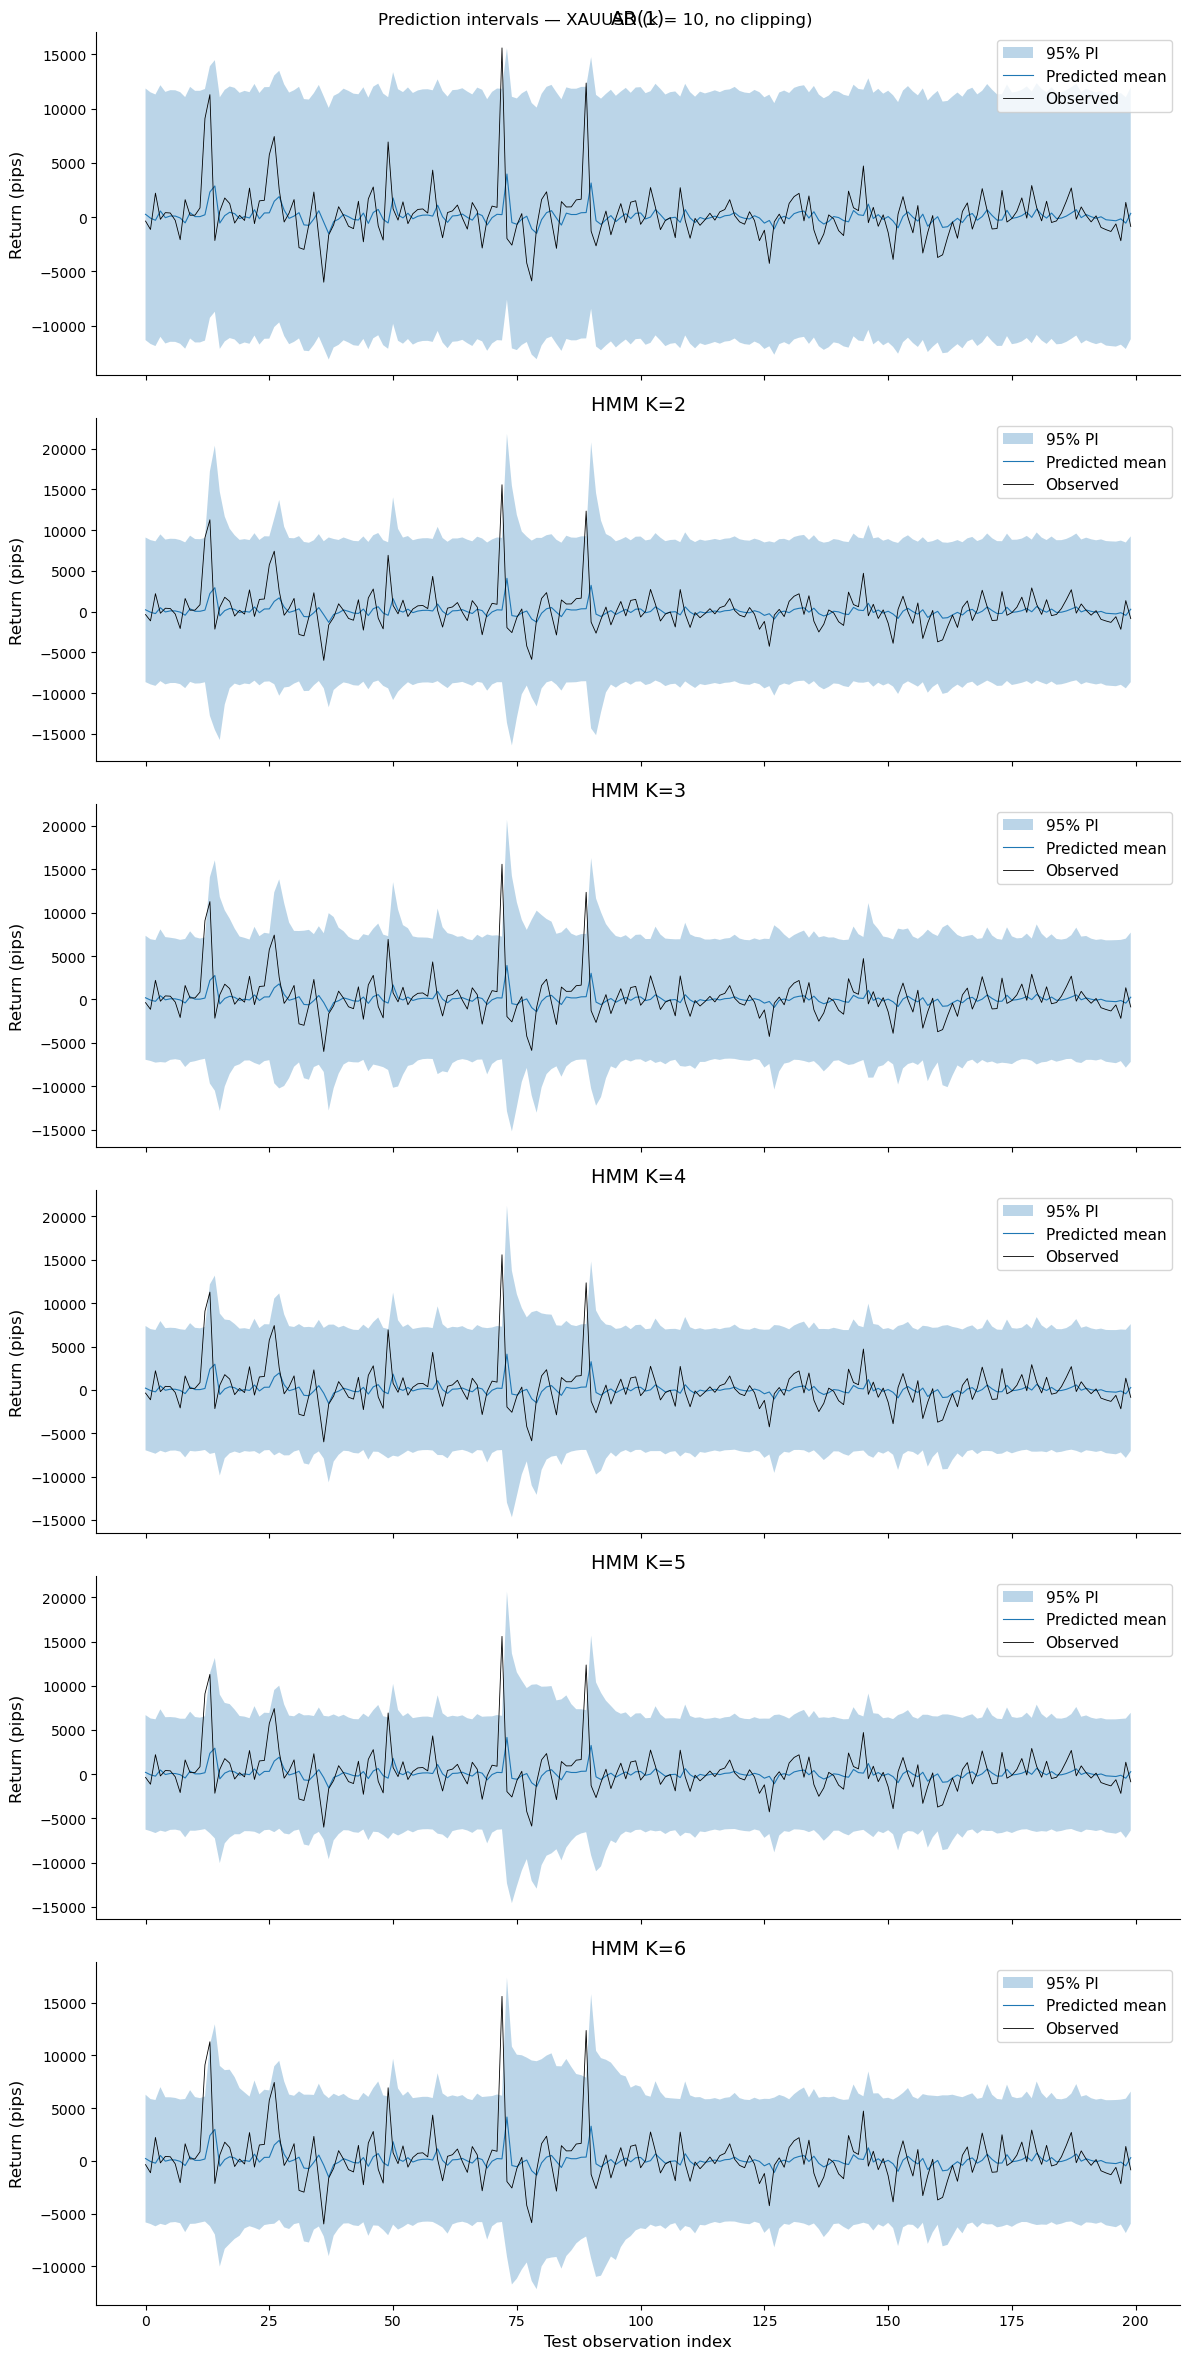

In [47]:
N_PLOT = 200

for market in markets:
    y_test = market_data[market]["y_test"]
    preds  = all_preds[market]
    t_plot = np.arange(N_PLOT)

    fig, axes = plt.subplots(len(preds), 1, figsize=(12, 4 * len(preds)), sharex=True)

    for ax, (label, (pred, lower, upper)) in zip(axes, preds.items()):
        ax.fill_between(t_plot, lower[:N_PLOT], upper[:N_PLOT], alpha=0.3, label="95% PI")
        ax.plot(t_plot, pred[:N_PLOT], linewidth=0.8, label="Predicted mean")
        ax.plot(t_plot, y_test[:N_PLOT], linewidth=0.6, color="black", label="Observed")
        ax.set_title(label)
        ax.set_ylabel("Return (pips)")
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Test observation index")
    fig.suptitle(f"Prediction intervals — {market} (k = {K_TICKS}, no clipping)")
    plt.tight_layout()
    plt.savefig(f"../plots/setup2_pred_intervals_{market.lower()}.pdf", bbox_inches="tight")
    plt.show()

## Save evaluation metrics to cache

In [44]:
for market in markets:
    results[market]["eval"] = {
        label: {k: float(v) for k, v in metrics.items()}
        for label, metrics in eval_records[market].items()
    }

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)
print(f"Evaluation metrics appended to {RESULTS_FILE}")

Evaluation metrics appended to setup2_results.json


## Vary pre-averaging level k

Repeat the analysis for k ∈ {5, 10, 20, 50} ticks.
Fits AR(1) and HMM K = 2, 3, 4 for each (k, market) combination.
Results cached under `"vary_k"` in the same JSON file.

In [45]:
k_values = [5, 10, 20, 50]

for market in markets:
    if "vary_k" not in results.get(market, {}):
        results[market]["vary_k"] = {}

for k in k_values:
    for market in markets:
        cached = results[market]["vary_k"].get(str(k), {})
        expected = ["AR(1)"] + [f"HMM K={K}" for K in K_PRED_VARY]
        if all(label in cached for label in expected):
            print(f"{market} k={k}: already cached, skipping")
            continue

        if str(k) not in results[market]["vary_k"]:
            results[market]["vary_k"][str(k)] = {}

        df_raw = load_data(market=market)
        tmp    = pre_avg(df_raw, tick=True, k=k)
        tmp    = compute_returns(tmp)
        y      = tmp["r"].values.astype(float) * 10_000
        sp     = int(TRAIN_FRAC * len(y))
        y_tr, y_te = y[:sp], y[sp:]
        results[market]["vary_k"][str(k)]["n_obs"] = len(y)

        if "AR(1)" not in cached:
            rho, sig = fit_single_ar1(y_tr)
            p, lo, up = predict_single_ar1(y_tr, y_te, rho, sig, alpha=0.05)
            results[market]["vary_k"][str(k)]["AR(1)"] = {
                "rho": float(rho), "sigma": float(sig),
                **{kk: float(vv) for kk, vv in
                   evaluate_predictions(y_te, p, lo, up, alpha=0.05).items()}
            }
            with open(RESULTS_FILE, "w") as f:
                json.dump(results, f, indent=2)

        for K in K_PRED_VARY:
            label = f"HMM K={K}"
            if label in cached:
                print(f"  {market} k={k} K={K}: already cached, skipping")
                continue
            print(f"  {market} k={k} K={K} ...", end=" ", flush=True)
            _, params = fit_hmm_robust(y_tr, K=K, n_starts=10, seed=42)
            p, lo, up = predict_hmm_mixture(y_tr, y_te, params, alpha=0.05)
            results[market]["vary_k"][str(k)][label] = {
                "beta":  params["beta"].tolist(),
                "sigma": params["sigma"].tolist(),
                "P":     params["P"].tolist(),
                **{kk: float(vv) for kk, vv in
                   evaluate_predictions(y_te, p, lo, up, alpha=0.05).items()}
            }
            with open(RESULTS_FILE, "w") as f:
                json.dump(results, f, indent=2)
            print("done  (saved)")

EURUSD k=5: already cached, skipping
USDJPY k=5: already cached, skipping
USDZAR k=5: already cached, skipping
XAUUSD k=5: already cached, skipping
EURUSD k=10: already cached, skipping
USDJPY k=10: already cached, skipping
USDZAR k=10: already cached, skipping
XAUUSD k=10: already cached, skipping
EURUSD k=20: already cached, skipping
USDJPY k=20: already cached, skipping
USDZAR k=20: already cached, skipping
XAUUSD k=20: already cached, skipping
EURUSD k=50: already cached, skipping
USDJPY k=50: already cached, skipping
USDZAR k=50: already cached, skipping
XAUUSD k=50: already cached, skipping


In [46]:
vary_k_records = []
for market in markets:
    for k in k_values:
        vk    = results[market].get("vary_k", {}).get(str(k), {})
        n_obs = vk.get("n_obs")
        for label in ["AR(1)"] + [f"HMM K={K}" for K in K_PRED]:
            if label in vk:
                row = {"market": market, "k": k, "method": label, "n_obs": n_obs}
                row.update({kk: vk[label][kk]
                             for kk in ["rmse", "coverage", "avg_width", "interval_score"]})
                vary_k_records.append(row)

if vary_k_records:
    vary_k_df = pd.DataFrame(vary_k_records).round(4)
    for market in markets:
        print(f"\n=== {market} ===")
        sub = vary_k_df[vary_k_df["market"] == market].drop(columns="market")
        print(sub.to_string(index=False))


=== EURUSD ===
 k  method  n_obs   rmse  coverage  avg_width  interval_score
 5   AR(1) 266024 0.2786    0.9684     1.2090          1.3745
 5 HMM K=2 266024 0.2786    0.9617     1.1676          1.3582
 5 HMM K=3 266024 0.2786    0.9582     1.1458          1.3529
 5 HMM K=4 266024 0.2786    0.9563     1.1338          1.3509
10   AR(1) 133012 0.3979    0.9667     1.7287          1.9508
10 HMM K=2 133012 0.3979    0.9607     1.6702          1.9302
10 HMM K=3 133012 0.3979    0.9567     1.6371          1.9252
10 HMM K=4 133012 0.3980    0.9530     1.6081          1.9213
20   AR(1)  66506 0.5663    0.9645     2.4378          2.7803
20 HMM K=2  66506 0.5663    0.9597     2.3616          2.7602
20 HMM K=3  66506 0.5663    0.9562     2.3239          2.7530
20 HMM K=4  66506 0.5663    0.9565     2.3146          2.7492
50   AR(1)  26602 0.8818    0.9709     3.8701          4.2785
50 HMM K=2  26602 0.8817    0.9632     3.7294          4.2334
50 HMM K=3  26602 0.8816    0.9605     3.6715         